In [1]:
import os
from os.path import expanduser
home = expanduser("~/")

import sys
# sys.path.insert(0, '/global/u2/x/xshuang/gigalens-xh-dev/src')

# import sys
conda_env = sys.path[1]
del sys.path[1]

import os
# sys.path.append(f'{os.environ['HOME']}/gigalens_personal/gigalens/src')
sys.path.append(home+'/gigalens'+'/src')
sys.path.append(conda_env)
sys.path.append(home+'/GIGALens-Code/')
print(sys.path)



srcdir = os.path.join(home, "gigalens/src/")


['', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '/usr/local/lib/python3.12/dist-packages', '__editable__.flax-0.10.6.finder.__path_hook__', '__editable__.jax_cuda12_pjrt-0.6.2.dev20250607.finder.__path_hook__', '__editable__.jax_cuda12_plugin-0.6.2.dev20250607.finder.__path_hook__', '__editable__.nsys_jax-0.1.dev1163+g4a8f06a.finder.__path_hook__', '/opt/pip/src', '/usr/lib/python3/dist-packages', '/global/homes/l/linusu//gigalens/src', '/global/homes/l/linusu/.conda/envs/gigalens_multinode_env/lib/python3.12/site-packages', '/global/homes/l/linusu//GIGALens-Code/']


In [2]:
import tensorflow_probability.substrates.jax as tfp

from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear, tnfw

import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
import corner
import yaml
import pickle
from helpers import *
import blackjax
import importlib
from alternate_inference.mclmc_alt import MCLMC
tfd = tfp.distributions

In [3]:

import gigalens
importlib.reload(gigalens)
from gigalens.jax.profiles.mass import tnfw_ellipse
import lenstronomy
from lenstronomy.Data.pixel_grid import PixelGrid
import functools
from typing import List, Dict

import jax
import jax.numpy as jnp
import numpy as np
from jax import jit
from jax import lax
from lenstronomy.Util.kernel_util import subgrid_kernel
from objax.constants import ConvPadding
from objax.functional import average_pool_2d
from gigalens.jax.simulator import LensSimulator
import gigalens.model
import gigalens.simulator
from helpers import *
import numpy as np, json

In [4]:
import functools
class ImageBasedLight(gigalens.profile.LightProfile):
    _name = "IMAGEBASEDLIGHT"
    _params = ["center_x", "center_y"]

    def __init__(self, image, image_pixel_scale, *args, **kwargs):
        super(ImageBasedLight, self).__init__(*args, **kwargs)
        if len(image.shape)!=2 and image.shape[0] != image.shape[1]:
            raise ValueError(f"Image must be square. Instead it is of shape {image.shape}")
        
        self.source_img = image
        num_pix = self.source_img.shape[0]
        self.image_pixel_scale = image_pixel_scale

        # self.transform_pix2angle = np.eye(2) * self.image_pixel_scale

        # lo = np.arange(0, num_pix, dtype=np.float32)
        # lo = np.min(lo - np.mean(lo))

        # ra_at_xy_0, dec_at_xy_0 = np.squeeze((self.transform_pix2angle @ ([[lo], [lo]])))

        # pixel_grid = PixelGrid(
        #     num_pix, num_pix,
        #     self.transform_pix2angle, ra_at_xy_0, dec_at_xy_0,
        # )
        # img_x, img_y = (
        #     pixel_grid._x_grid.astype(np.float32),
        #     pixel_grid._y_grid.astype(np.float32),
        # )
        # print(f"From {np.min(img_x)} to {np.max(img_x)}")
        half_extent = (num_pix - 1) / 2.0 * self.image_pixel_scale
        x_1d = np.linspace(-half_extent, half_extent, num_pix).astype(np.float32)
        y_1d = np.linspace(-half_extent, half_extent, num_pix).astype(np.float32)
        self.interpolator = jax.scipy.interpolate.RegularGridInterpolator(
            (x_1d, y_1d), self.source_img, method='linear', fill_value=0.0
        )
        # self.interpolator = jax.scipy.interpolate.RegularGridInterpolator((img_x, img_y), self.source_img, method='linear', fill_value=0.0)

    # @functools.partial(jax.jit, static_argnums=(0,))
    def light(self, x, y, center_x, center_y,):
        points = jnp.stack([x-center_x, y-center_y], axis=-1)
        return self.interpolator(points)

import lenstronomy.Util.image_util as image_util
def noise_images(imgs, exp_time=100, background_rms=0.2):
    noised_images = []
    #* Add noise
    for lens_img in imgs:
        poisson = image_util.add_poisson(lens_img, exp_time=exp_time)
        bkg = image_util.add_background(lens_img, sigma_bkd=background_rms) # gaussian, mean is 0
        noised_images.append(lens_img + poisson + bkg) 

    return noised_images

In [5]:
#* Initialize Priors
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.25), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(0, 0.03),
                center_y=tfd.Normal(0, 0.03),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.07), gamma2=tfd.Normal(0, 0.07)) #* Raised spreadx
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.6), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.05, -0.15, 0.15),
                e2=tfd.TruncatedNormal(0, 0.05, -0.15, 0.15),
                center_x=tfd.Normal(0, 0.01),
                center_y=tfd.Normal(0, 0.01),
                Ie=tfd.LogNormal(jnp.log(20.0), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior,source_light_prior]
)

2026-04-06 16:48:30.689705: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng39{k2=0,k12=1,k13=2,k14=3,k15=0,k17=1,k18=1,k23=0} for conv %cudnn-conv = (f32[1,1,800,800]{3,2,1,0}, u8[0]{0}) custom-call(%bitcast.24, %constant.28), window={size=99x99 pad=49_49x49_49}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", metadata={op_name="jit(simulate)/jit(main)/simulate/conv_pool/conv_general_dilated" source_file="/global/homes/l/linusu//gigalens/src/gigalens/jax/simulator.py" source_line=189}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-04-06 16:48:31.796058: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 2.106482681s
Trying algorithm eng39{k2=0,k12=1,k13=2,k14=3,k15=0,k17=1,k18=1,k23=0} for co

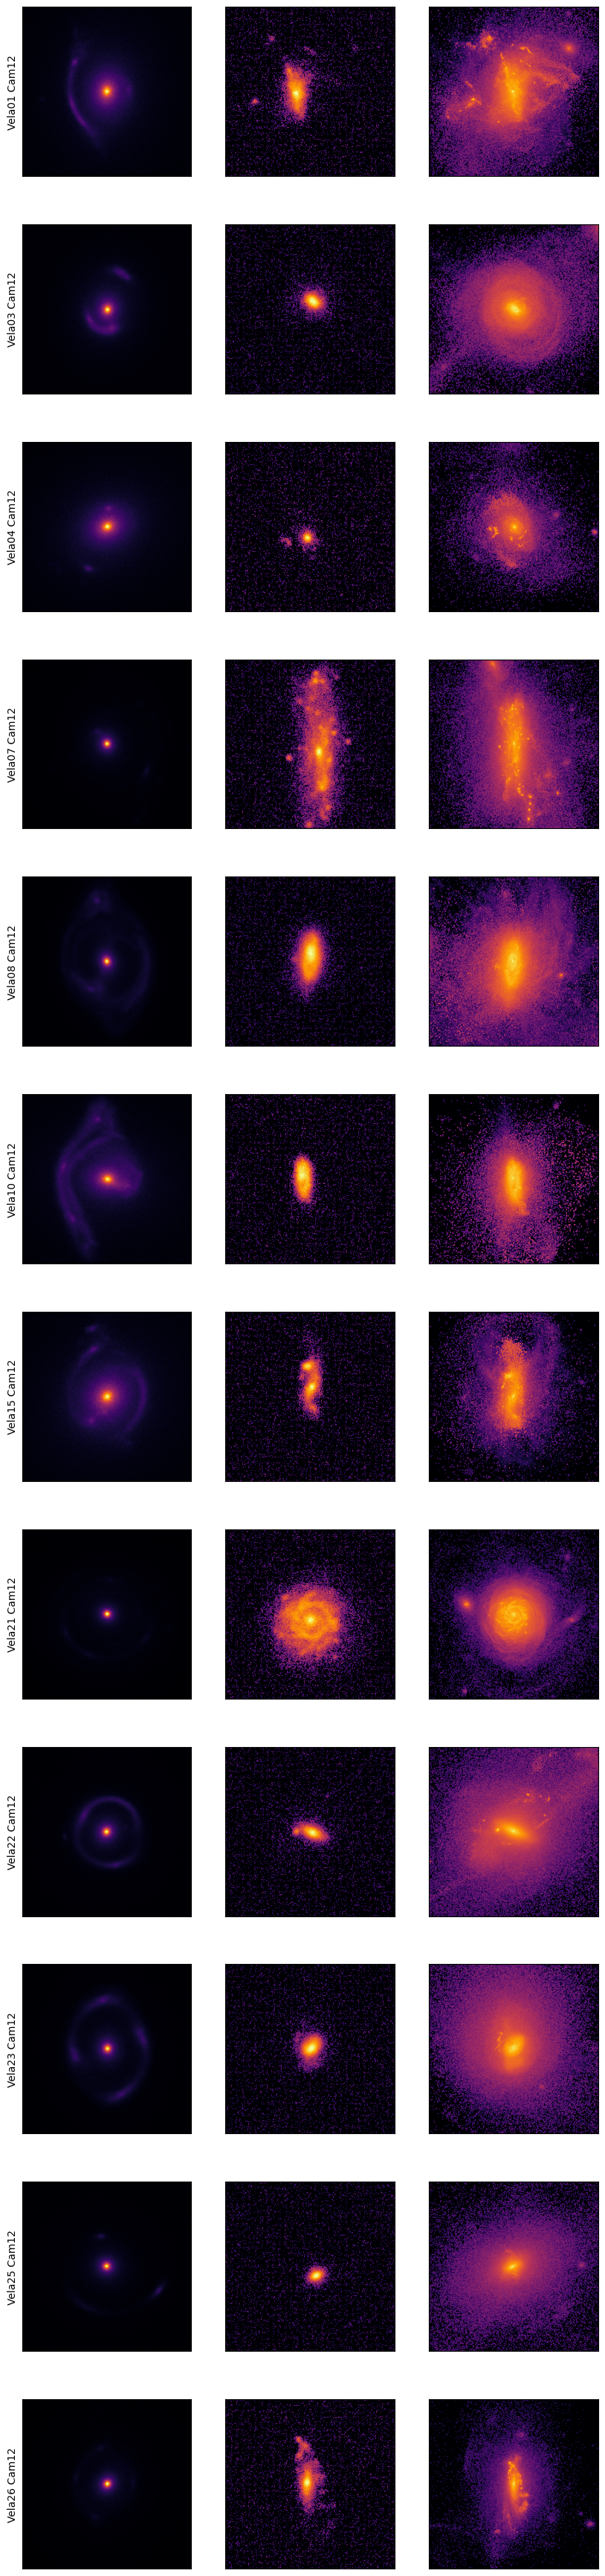

In [14]:
from tqdm import tqdm

random_params = prior.sample(12, seed=jax.random.PRNGKey(1))
sim_nums = ["01", "03", "04", "07", "08", "10", "15", "21", "22", "23", "25", "26"]
# cams = ["00", "12"]
cam = "12"

background_rms = 0.002
exp_time = 2000

fig, axs = plt.subplots(12, 3)
fig.set_size_inches(10, 45)


current_dir = os.path.join(home, f"GIGALens-Code/source_modeling/")
for i, sim_num in tqdm(enumerate(sim_nums)):
    # print(f"Vela{sim_num} Cam{cam}")
    ax1, ax2, ax3 = axs[i]
    lens_params = jax.tree.map(lambda x : x[i][jnp.newaxis], random_params)
    # lens_params.append([{}])
    
    source_plane_dir = os.path.join(current_dir, f"vela_sources/vela{sim_num}_cam{cam}_a0.500_f814w/")
    save_dir = os.path.join(current_dir, f"vela_sim_systems/vela{sim_num}_cam{cam}_a0.500_f814w/")

    if not os.path.exists(save_dir):
        os.mkdir(save_dir)

    
    #* Load image
    source_img_nJy = np.load(os.path.join(source_plane_dir, "source_image.npy"))
    psf    = np.load(os.path.join(source_plane_dir, "psf.npy"))
    with open(os.path.join(source_plane_dir, "metadata.json")) as f:
        meta = json.load(f)
    
    
    source_img_pixel_scale = meta['source_pixel_scale_arcsec']
    delta_pix = meta['instrument_pixel_scale_arcsec']
    num_pix = 200
    
    SB_nJy_per_arcsec2 = source_img_nJy / (source_img_pixel_scale**2)
    
    SB_cps_per_arcsec2 = SB_nJy_per_arcsec2* 1e-9 /meta["photfnu_Jy"]
    sim_config = SimulatorConfig(delta_pix=delta_pix, num_pix=num_pix, supersample=4, kernel=psf)
    vela_light = ImageBasedLight(SB_cps_per_arcsec2, source_img_pixel_scale)

    
    #* Display raw source
    n = SB_nJy_per_arcsec2.shape[0]
    dpx = source_img_pixel_scale
    extent = [-n*dpx/2, n*dpx/2, -n*dpx/2, n*dpx/2]
    plot_image(fig, ax3, SB_nJy_per_arcsec2.T, extent=extent, remove_axis=True, colorbar=False, log_vmin=1e-1, log_norm=True)
    # ax3.imshow(SB_nJy_per_arcsec2.T, norm = matplotlib.colors.LogNorm(vmin=1e-3,clip=True), extent=extent,cmap='inferno')

    #* Simulate Unlensed Source
    phys_model = PhysicalModel([], [], [vela_light])
    lens_sim = LensSimulator(phys_model, sim_config, bs=1)
    
    sim_src = lens_sim.simulate([[], lens_params[2]]) # Choose 1st archetypal system
    
    sim_src_noised = noise_images([sim_src], exp_time=exp_time, background_rms=background_rms)[0]

    #* Display Unlensed Source
    n = num_pix
    dpx = delta_pix
    extent = [-n*dpx/2, n*dpx/2, -n*dpx/2, n*dpx/2]
    plot_image(fig, ax2, sim_src_noised, extent=extent, remove_axis=True, colorbar=False, log_vmin=1e-3, log_norm=True)
    # ax2.imshow(sim_src_noised, norm = matplotlib.colors.LogNorm(vmin=1e-4, clip=True), extent=extent,cmap='inferno')

    #* Simulate Lensed Source
    phys_model_real = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),], [vela_light])
    lens_sim_real = LensSimulator(phys_model_real, sim_config, bs=1)

    sim_lens = lens_sim_real.simulate(lens_params) # Choose 1st archetypal system
    sim_lens_noised = noise_images([sim_lens], exp_time=exp_time, background_rms=background_rms)[0]

    #* Display Lensed Source
    dx = sim_config.delta_pix
    n = sim_config.num_pix
    dim = dx*n
    extent = [-dim/2, dim/2, -dim/2, dim/2,]
    fig, ax = plt.gcf(), plt.gca()
    plot_image(fig, ax1, sim_lens_noised, extent=extent, remove_axis=True, colorbar=False,log_vmin=1e-3, log_norm=False)
    ax1.set_ylabel(f"Vela{sim_num} Cam{cam}")

    #* Save all outputs
    
    with open(os.path.join(save_dir, "true_params"), 'wb') as file_handle:
        pickle.dump(lens_params, file_handle)
    jnp.save(os.path.join(save_dir, "src_img"), sim_src_noised)
    jnp.save(os.path.join(save_dir, "lens_img"), sim_lens_noised)
    
plt.savefig(os.path.join(current_dir, f"vela_sim_systems/lens_plots.png"))
plt.show()

In [7]:
# true_params = ([
    # {'theta_E': np.array([1.2,]), 
    #  'gamma': np.array([1.5,]), 
    #  'e1': np.array([0.1,]), 
    #  'e2': np.array([0.03,]), 
    #  'center_x': np.array([0.01,]), 
    #  'center_y': np.array([0.2,])},
    
    # {'gamma1': np.array([0,]), 
    #  'gamma2': np.array([0.16,])}
    
# ], [
#     {'R_sersic': np.array([0.91,]), 
#      'n_sersic': np.array([2.0,]), 
#      'e1': np.array([-0.02,]), 
#      'e2': np.array([0.05,]), 
#      'center_x': np.array([0.01,]), 
#      'center_y': np.array([0.2,]), 
#      'Ie': np.array([40.0,])},
#    ],
    
#     [
#         {}
#     ])



#epl.EPL(50), 
phys_model_real = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False),], [vela_light])
lens_sim_real = LensSimulator(phys_model_real, sim_config, bs=1)

sim_lens = lens_sim_real.simulate(true_params) # Choose 1st archetypal system
# background_rms = 0.002#0.002
# exp_time = 2000
sim_lens_noised = noise_images([sim_lens], exp_time=exp_time, background_rms=background_rms)[0]
noise_map = get_noise_image(sim_lens, background_rms, exp_time)
# np.save(os.path.join(save_dir, "lens_img"), sim_lens_noised)
# import pickle
# with open(os.path.join(save_dir, "true_params"), 'wb') as file_handle:
#     pickle.dump(true_params, file_handle)

NameError: name 'true_params' is not defined

In [ ]:
# img = sim_lens
dx = sim_config.delta_pix
n = sim_config.num_pix
dim = dx*n
extent = [-dim/2, dim/2, -dim/2, dim/2,]
fig, ax = plt.gcf(), plt.gca()
plot_image(fig, ax, sim_lens_noised, extent=extent, remove_axis=False, log_vmin=1e-4, log_norm=False)
plt.show()